# 02B - Fast, Accuracy-Preserving Faster R-CNN

This is the successor to `02_Faster_RCNN_BDD100K_Training.ipynb`; the original
executed notebook remains unchanged. It keeps the higher-quality
MobileNetV3-Large FPN detector at 480/640 resolution and removes the measured
Region Proposal Network bottleneck.

The default RTX 3050 profile uses short, rotating 700-image epochs. It is designed
to approach two minutes per epoch after CUDA warm-up while accumulating broad
dataset coverage across 70 epochs. Final validation and test F1/mAP are measured,
not inferred from training loss or confidence scores.

## Why this version is faster

The interrupted `02` run reached only 2 of 600 images after 4:03, about 122 seconds
per image. A controlled benchmark found the default 2,000 training proposals were
the primary cause. On the same 150 validation images, the balanced proposal budget
was 2.6 times faster and did not reduce the untrained COCO-transfer metrics:

| configuration | validation time | images/s | F1@0.25 | mAP50 |
|---|---:|---:|---:|---:|
| Torchvision defaults | 28.83 s | 5.20 | 0.2318 | 0.1591 |
| balanced proposals | 11.09 s | 13.52 | 0.2330 | 0.1600 |

BDD100K label profiling also found a maximum of 85 objects in an image and a 99th
percentile of 46, so retaining 512 post-NMS training proposals still leaves several
candidate regions per labeled object even in dense scenes.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import math
import random
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from road_detection.constants import PROJECT_CLASSES
from road_detection.rcnn_dataset import (
    RareClassBalancedSampler,
    YoloDetectionDataset,
    collate_fn,
)
from road_detection.rcnn_metrics import (
    collect_predictions,
    evaluate_operating_points,
    evaluate_predictions,
    tune_score_threshold,
)
from road_detection.rcnn_model import (
    FAST_ACCURATE_RCNN_CONFIG,
    build_faster_rcnn,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = DEVICE.type == "cuda"

print("PyTorch:", torch.__version__)
print("Torchvision CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

c:\tf214_hw2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cu126
Torchvision CUDA available: True
Device: cuda NVIDIA GeForce RTX 3050 Laptop GPU


## Run profile

`rtx3050_fast` is the recommended run for `C:\tf214_hw2`. `smoke` verifies the
pipeline quickly. `accuracy` doubles the images per epoch and final evaluation
size when elapsed time matters less than the strongest result.

The 0.80 target below is an acceptance target, not a promised outcome. Object
detection F1 and mAP are different from classification accuracy, and a confidence
score is not itself a correctness probability.

In [2]:
RUN_MODE = "rtx3050_fast"  # smoke | rtx3050_fast | accuracy
RESUME = True
TARGET_F1 = 0.80
MIN_LIVE_CONFIDENCE = 0.70

PROFILES = {
    "smoke": dict(
        epochs=2, pool_images=1000, images_per_epoch=64, batch=4, workers=0,
        proxy_val_images=48, final_eval_images=96,
        head_only_epochs=1, patience=99, minimum_epochs=2, benchmark_images=24,
    ),
    "rtx3050_fast": dict(
        epochs=70, pool_images=12000, images_per_epoch=700, batch=8, workers=0,
        proxy_val_images=150, final_eval_images=1000,
        head_only_epochs=4, patience=15, minimum_epochs=30, benchmark_images=100,
    ),
    "accuracy": dict(
        epochs=80, pool_images=24000, images_per_epoch=1600, batch=8, workers=0,
        proxy_val_images=300, final_eval_images=2000,
        head_only_epochs=5, patience=18, minimum_epochs=35, benchmark_images=100,
    ),
}
cfg = PROFILES[RUN_MODE]
if DEVICE.type != "cuda" and RUN_MODE != "smoke":
    raise RuntimeError("Use RUN_MODE='smoke' on CPU. The fast training profiles require CUDA.")

DATASET_ROOT = ROOT / "data" / "bdd100k_yolo"
MODEL_DIR = ROOT / "models" / "fasterrcnn_02b"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_WEIGHTS = MODEL_DIR / f"{RUN_MODE}_best.pth"
LAST_WEIGHTS = MODEL_DIR / f"{RUN_MODE}_last.pth"
REPORT_PATH = MODEL_DIR / f"{RUN_MODE}_evaluation.json"

MODEL_KWARGS = dict(
    num_classes=len(PROJECT_CLASSES) + 1,
    variant="mobilenet",
    min_size=480,
    max_size=640,
    trainable_backbone_layers=2,
    pretrained=True,
    class_names=PROJECT_CLASSES,
    transfer_coco_head=True,
    performance_config=FAST_ACCURATE_RCNN_CONFIG,
)

print(json.dumps(cfg, indent=2))
print("Dataset:", DATASET_ROOT)
print("Best checkpoint:", BEST_WEIGHTS)

{
  "epochs": 70,
  "pool_images": 12000,
  "images_per_epoch": 700,
  "batch": 8,
  "workers": 0,
  "proxy_val_images": 150,
  "final_eval_images": 1000,
  "head_only_epochs": 4,
  "patience": 15,
  "minimum_epochs": 30,
  "benchmark_images": 100
}
Dataset: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\data\bdd100k_yolo
Best checkpoint: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\models\fasterrcnn_02b\rtx3050_fast_best.pth


## Data and rotating class-aware epochs

Every epoch samples different scenes without replacement from a seeded 12,000-image
curriculum pool. Reusing that pool across 70 epochs gives each scene enough training
exposure while avoiding a slow scan of all 70,000 OneDrive-backed label files. The
class metadata is cached after its first scan. Image weights use the square root of
inverse class frequency, capped at 4x, so buses and trucks receive more opportunities
without allowing a rare class to dominate training.

In [3]:
def seeded_subset(dataset, limit, seed):
    if limit is None or limit >= len(dataset):
        return dataset
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:limit].tolist()
    return Subset(dataset, indices)


train_ds = YoloDetectionDataset(DATASET_ROOT, "train", max_size=640, augment=True)
val_ds = YoloDetectionDataset(DATASET_ROOT, "val", max_size=640, augment=False)
test_dir = DATASET_ROOT / "images" / "test"
test_ds = (
    YoloDetectionDataset(DATASET_ROOT, "test", max_size=640, augment=False)
    if test_dir.exists() and any(test_dir.iterdir())
    else None
)

pool_size = min(cfg["pool_images"], len(train_ds))
pool_generator = torch.Generator().manual_seed(SEED + 100)
candidate_indices = torch.randperm(len(train_ds), generator=pool_generator)[:pool_size].tolist()
sampler_cache = MODEL_DIR / f"sampler_{pool_size}_seed{SEED}.json"
epoch_sampler = RareClassBalancedSampler(
    train_ds,
    num_samples=min(cfg["images_per_epoch"], pool_size),
    num_classes=len(PROJECT_CLASSES),
    seed=SEED,
    rarity_exponent=0.5,
    max_weight=4.0,
    candidate_indices=candidate_indices,
    cache_path=sampler_cache,
    scan_workers=8,
)
proxy_val_ds = seeded_subset(val_ds, cfg["proxy_val_images"], SEED + 1)

loader_options = dict(
    num_workers=cfg["workers"],
    collate_fn=collate_fn,
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=cfg["workers"] > 0,
)
train_loader = DataLoader(
    train_ds,
    batch_size=cfg["batch"],
    sampler=epoch_sampler,
    **loader_options,
)
proxy_val_loader = DataLoader(
    proxy_val_ds,
    batch_size=cfg["batch"],
    shuffle=False,
    **loader_options,
)

class_balance = pd.DataFrame({
    "class": PROJECT_CLASSES,
    "images_in_curriculum_pool": epoch_sampler.class_image_counts.int().tolist(),
    "sampling_weight": epoch_sampler.class_weights.tolist(),
})
display(class_balance.style.format({"sampling_weight": "{:.2f}"}))
print(f"Training images: {len(train_ds):,}")
print(f"Rotating curriculum pool: {pool_size:,}")
print(f"Unique images sampled per epoch: {len(epoch_sampler):,}")
print(f"Optimizer steps per epoch: {len(train_loader):,}")
print(f"Proxy validation images: {len(proxy_val_ds):,}")

,class,images_in_curriculum_pool,sampling_weight
0,car,11868,1.00
1,bus,1535,2.78
2,truck,3181,1.93
3,pedestrian,3761,1.78
4,traffic light,6723,1.33
5,traffic sign,9752,1.10


Training images: 70,000
Rotating curriculum pool: 12,000
Unique images sampled per epoch: 700
Optimizer steps per epoch: 88
Proxy validation images: 150


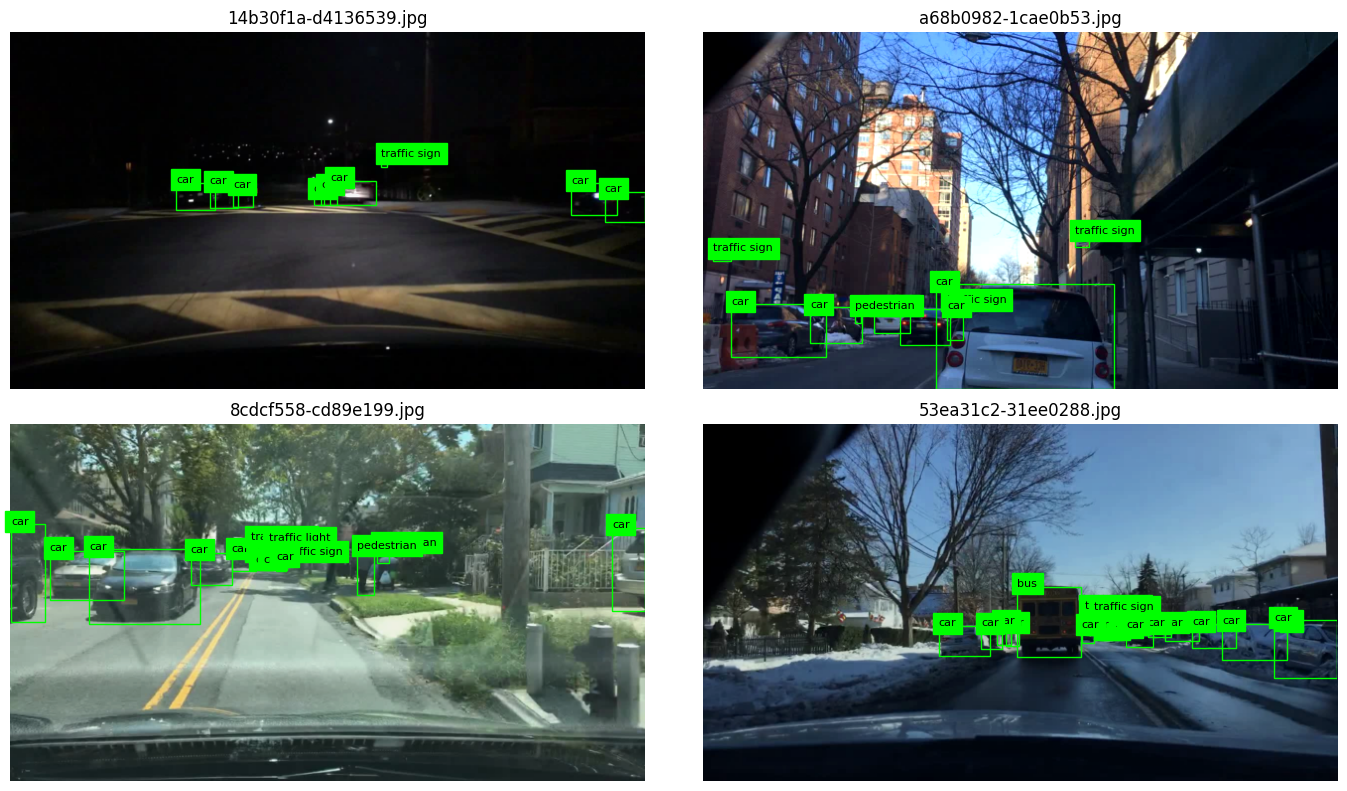

In [4]:
epoch_sampler.set_epoch(0)
preview_indices = epoch_sampler.sample_indices()[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for axis, index in zip(axes.flat, preview_indices):
    image, target = train_ds[index]
    axis.imshow(image.permute(1, 2, 0).clamp(0, 1))
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", linewidth=1))
        axis.text(x1, y1, PROJECT_CLASSES[int(label) - 1], color="black", fontsize=8, backgroundcolor="lime")
    axis.set_title(train_ds.images[index].name)
    axis.axis("off")
plt.tight_layout()

## Model, staged fine-tuning, and resume support

The six-class predictor copies matching COCO weights instead of starting randomly.
For the first few epochs, the RPN and ROI heads adapt while the already-trained
backbone is frozen. The last two MobileNet backbone stages then unfreeze at a lower
learning rate. The last completed epoch is saved separately from the best validation
checkpoint, so an interrupted overnight run can resume.

In [5]:
model = build_faster_rcnn(**MODEL_KWARGS).to(DEVICE)

backbone_parameters = [parameter for parameter in model.backbone.parameters() if parameter.requires_grad]
backbone_parameter_ids = {id(parameter) for parameter in backbone_parameters}
head_parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad and id(parameter) not in backbone_parameter_ids
]

optimizer = torch.optim.AdamW(
    [
        {"params": head_parameters, "lr": 3e-4, "name": "heads"},
        {"params": backbone_parameters, "lr": 8e-5, "name": "backbone"},
    ],
    weight_decay=1e-4,
)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")


def set_backbone_trainable(enabled):
    for parameter in backbone_parameters:
        parameter.requires_grad_(enabled)


def set_epoch_learning_rates(epoch):
    progress = (epoch - 1) / max(1, cfg["epochs"] - 1)
    cosine = 0.05 + 0.95 * 0.5 * (1.0 + math.cos(math.pi * progress))
    warmup = min(1.0, epoch / 3.0)
    optimizer.param_groups[0]["lr"] = 3e-4 * cosine * warmup
    optimizer.param_groups[1]["lr"] = (
        8e-5 * cosine * warmup if epoch > cfg["head_only_epochs"] else 0.0
    )


trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Initial trainable parameters: {trainable:,}")
print("Performance config:", FAST_ACCURATE_RCNN_CONFIG.to_dict())

Initial trainable parameters: 18,174,518
Performance config: {'rpn_pre_nms_top_n_train': 1000, 'rpn_pre_nms_top_n_test': 600, 'rpn_post_nms_top_n_train': 512, 'rpn_post_nms_top_n_test': 300, 'rpn_batch_size_per_image': 256, 'box_batch_size_per_image': 384, 'detections_per_image': 100}


In [6]:
def quick_tune(predictions, targets):
    thresholds = np.arange(0.10, 0.81, 0.05)
    return tune_score_threshold(
        predictions,
        targets,
        thresholds=thresholds.tolist(),
        class_names=PROJECT_CLASSES,
        compute_map=False,
    )


def evaluate_proxy():
    started = time.perf_counter()
    predictions, targets = collect_predictions(model, proxy_val_loader, DEVICE)
    metrics = quick_tune(predictions, targets)
    return metrics, time.perf_counter() - started


def checkpoint_payload(epoch, history, best_f1, score_threshold, include_optimizer):
    payload = {
        "model": model.state_dict(),
        "classes": PROJECT_CLASSES,
        "epoch": epoch,
        "history": history,
        "best_f1": best_f1,
        "score_threshold": score_threshold,
        "variant": "mobilenet",
        "min_size": 480,
        "max_size": 640,
        "performance_config": FAST_ACCURATE_RCNN_CONFIG.to_dict(),
        "run_mode": RUN_MODE,
        "training_profile": cfg,
    }
    if include_optimizer:
        payload["optimizer"] = optimizer.state_dict()
        payload["scaler"] = scaler.state_dict()
    return payload


def train_one_epoch(epoch):
    model.train()
    epoch_sampler.set_epoch(epoch)
    set_backbone_trainable(epoch > cfg["head_only_epochs"])
    set_epoch_learning_rates(epoch)
    running_loss = 0.0
    processed = 0
    started = time.perf_counter()
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg['epochs']}", leave=True)
    for images, targets in progress:
        images = [image.to(DEVICE, non_blocking=True) for image in images]
        targets = [
            {key: value.to(DEVICE, non_blocking=True) for key, value in target.items()}
            for target in targets
        ]
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=DEVICE.type == "cuda"):
            loss_parts = model(images, targets)
            loss = sum(loss_parts.values())
        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at epoch {epoch}: {loss_parts}")
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [parameter for parameter in model.parameters() if parameter.requires_grad],
            max_norm=5.0,
        )
        scaler.step(optimizer)
        scaler.update()
        batch_size = len(images)
        processed += batch_size
        running_loss += float(loss.detach()) * batch_size
        progress.set_postfix(
            loss=f"{running_loss / processed:.4f}",
            head_lr=f"{optimizer.param_groups[0]['lr']:.1e}",
        )
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    return running_loss / max(1, processed), elapsed

## Train

The first CUDA pass may take about 30 seconds while kernels initialize; steady
epochs are the meaningful speed comparison. Validation uses a fixed proxy split
every epoch and tunes only the operating threshold. Full mAP is reserved for final
model evaluation because repeatedly recomputing it does not improve training.

In [7]:
history = []
start_epoch = 1
best_f1 = -1.0
epochs_without_improvement = 0

if RESUME and LAST_WEIGHTS.exists():
    resume_checkpoint = torch.load(LAST_WEIGHTS, map_location=DEVICE, weights_only=False)
    model.load_state_dict(resume_checkpoint["model"])
    optimizer.load_state_dict(resume_checkpoint["optimizer"])
    if resume_checkpoint.get("scaler"):
        scaler.load_state_dict(resume_checkpoint["scaler"])
    history = resume_checkpoint.get("history", [])
    best_f1 = float(resume_checkpoint.get("best_f1", -1.0))
    start_epoch = int(resume_checkpoint["epoch"]) + 1
    print(f"Resuming after epoch {start_epoch - 1}; best proxy F1={best_f1:.4f}")
else:
    baseline_metrics, baseline_seconds = evaluate_proxy()
    best_f1 = baseline_metrics.f1
    torch.save(
        checkpoint_payload(
            epoch=0,
            history=[],
            best_f1=best_f1,
            score_threshold=baseline_metrics.score_threshold,
            include_optimizer=False,
        ),
        BEST_WEIGHTS,
    )
    print(
        f"COCO-transfer baseline: F1={baseline_metrics.f1:.4f}, "
        f"P={baseline_metrics.precision:.4f}, R={baseline_metrics.recall:.4f}, "
        f"threshold={baseline_metrics.score_threshold:.2f}, "
        f"evaluation={baseline_seconds:.1f}s"
    )

for epoch in range(start_epoch, cfg["epochs"] + 1):
    train_loss, train_seconds = train_one_epoch(epoch)
    proxy_metrics, validation_seconds = evaluate_proxy()
    improved = proxy_metrics.f1 > best_f1 + 1e-4
    if improved:
        best_f1 = proxy_metrics.f1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "precision": proxy_metrics.precision,
        "recall": proxy_metrics.recall,
        "f1": proxy_metrics.f1,
        "score_threshold": proxy_metrics.score_threshold,
        "train_seconds": train_seconds,
        "validation_seconds": validation_seconds,
        "images_per_second": len(epoch_sampler) / train_seconds,
        "backbone_trainable": epoch > cfg["head_only_epochs"],
    }
    history.append(row)

    if improved:
        torch.save(
            checkpoint_payload(
                epoch=epoch,
                history=history,
                best_f1=best_f1,
                score_threshold=proxy_metrics.score_threshold,
                include_optimizer=False,
            ),
            BEST_WEIGHTS,
        )
        print(f"Saved new best checkpoint: proxy F1={best_f1:.4f}")

    torch.save(
        checkpoint_payload(
            epoch=epoch,
            history=history,
            best_f1=best_f1,
            score_threshold=proxy_metrics.score_threshold,
            include_optimizer=True,
        ),
        LAST_WEIGHTS,
    )
    print(json.dumps(row, indent=2))

    if (
        epoch >= cfg["minimum_epochs"]
        and epochs_without_improvement >= cfg["patience"]
    ):
        print(f"Early stopping after {epochs_without_improvement} epochs without proxy F1 improvement.")
        break

print(f"Best proxy F1: {best_f1:.4f}")
print("Best weights:", BEST_WEIGHTS)

COCO-transfer baseline: F1=0.2393, P=0.3570, R=0.1799, threshold=0.30, evaluation=37.5s


Epoch 1/70: 100%|██████████| 88/88 [01:48<00:00,  1.23s/it, head_lr=1.0e-04, loss=0.7744]


{
  "epoch": 1,
  "train_loss": 0.7743664097785949,
  "precision": 0.35174418604651164,
  "recall": 0.18066442702500934,
  "f1": 0.23871763255240447,
  "score_threshold": 0.3500000000000001,
  "train_seconds": 108.41451540007256,
  "validation_seconds": 11.310448300093412,
  "images_per_second": 6.456699985392652,
  "backbone_trainable": false
}


Epoch 2/70: 100%|██████████| 88/88 [01:27<00:00,  1.01it/s, head_lr=2.0e-04, loss=0.7534]


Saved new best checkpoint: proxy F1=0.2429
{
  "epoch": 2,
  "train_loss": 0.753449729510716,
  "precision": 0.47249190938511326,
  "recall": 0.16349384098544234,
  "f1": 0.24292845257903498,
  "score_threshold": 0.3500000000000001,
  "train_seconds": 87.13541929994244,
  "validation_seconds": 11.688369199982844,
  "images_per_second": 8.033472560571731,
  "backbone_trainable": false
}


...

{
  "epoch": 58,
  "train_loss": 0.6683135407311576,
  "precision": 0.5,
  "recall": 0.23105636431504292,
  "f1": 0.3160582078121011,
  "score_threshold": 0.40000000000000013,
  "train_seconds": 409.10363560006954,
  "validation_seconds": 116.85525599995162,
  "images_per_second": 1.7110578813929294,
  "backbone_trainable": true
}


Epoch 59/70: 100%|██████████| 88/88 [10:05<00:00,  6.88s/it, head_lr=3.3e-05, loss=0.6661]


{
  "epoch": 59,
  "train_loss": 0.6660740559441702,
  "precision": 0.5212585034013606,
  "recall": 0.2288167226577081,
  "f1": 0.3180285343709468,
  "score_threshold": 0.40000000000000013,
  "train_seconds": 605.3458164000185,
  "validation_seconds": 12.554927699966356,
  "images_per_second": 1.1563638188876704,
  "backbone_trainable": true
}


Epoch 60/70: 100%|██████████| 88/88 [01:53<00:00,  1.30s/it, head_lr=3.0e-05, loss=0.6640]


{
  "epoch": 60,
  "train_loss": 0.6640012424332755,
  "precision": 0.5281873373807459,
  "recall": 0.22732362821948487,
  "f1": 0.3178496868475991,
  "score_threshold": 0.40000000000000013,
  "train_seconds": 113.9864077999955,
  "validation_seconds": 13.533929100027308,
  "images_per_second": 6.141083077451166,
  "backbone_trainable": true
}
Early stopping after 15 epochs without proxy F1 improvement.
Best proxy F1: 0.3219
Best weights: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\models\fasterrcnn_02b\rtx3050_fast_best.pth


,epoch,train_loss,precision,recall,f1,score_threshold,train_seconds,validation_seconds,images_per_second,backbone_trainable
50,51,0.6609,0.480,0.228,0.310,0.35,579.7,56.8,1.2,True
51,52,0.6609,0.423,0.247,0.312,0.30,104.2,12.5,6.7,True
52,53,0.6639,0.465,0.238,0.315,0.35,210.3,98.9,3.3,True
53,54,0.6728,0.521,0.222,0.311,0.40,577.4,11.4,1.2,True
54,55,0.6633,0.473,0.238,0.317,0.35,110.9,12.6,6.3,True
55,56,0.6538,0.433,0.246,0.314,0.30,625.8,12.2,1.1,True
56,57,0.6654,0.483,0.236,0.317,0.35,109.2,12.7,6.4,True
57,58,0.6683,0.500,0.231,0.316,0.40,409.1,116.9,1.7,True
58,59,0.6661,0.521,0.229,0.318,0.40,605.3,12.6,1.2,True
59,60,0.6640,0.528,0.227,0.318,0.40,114.0,13.5,6.1,True


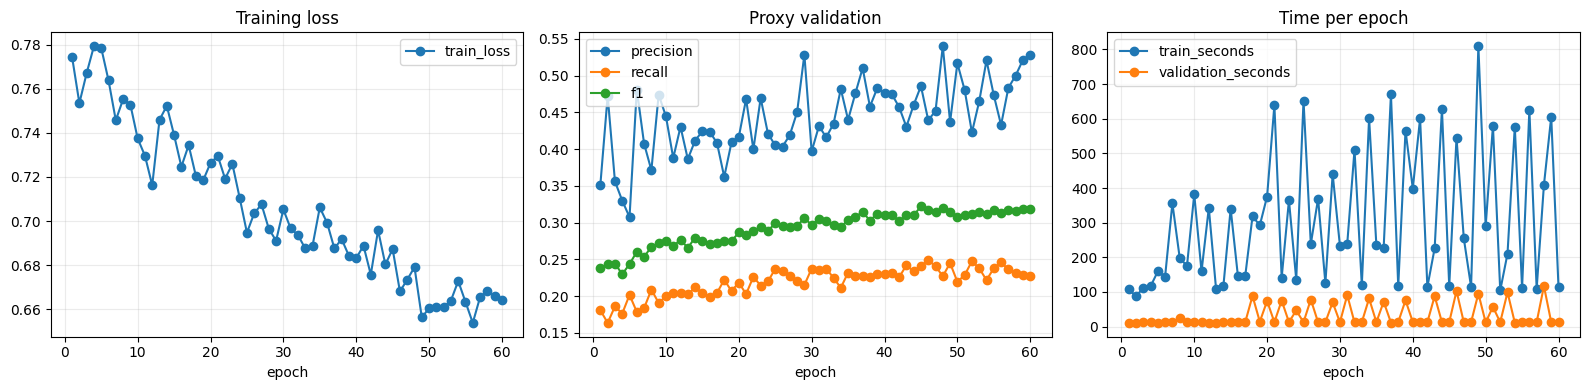

In [8]:
history_df = pd.DataFrame(history)
if len(history_df):
    display(history_df.tail(10).style.format({
        "train_loss": "{:.4f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "score_threshold": "{:.2f}",
        "train_seconds": "{:.1f}",
        "validation_seconds": "{:.1f}",
        "images_per_second": "{:.1f}",
    }))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    history_df.plot(x="epoch", y="train_loss", marker="o", ax=axes[0], title="Training loss")
    history_df.plot(x="epoch", y=["precision", "recall", "f1"], marker="o", ax=axes[1], title="Proxy validation")
    history_df.plot(x="epoch", y=["train_seconds", "validation_seconds"], marker="o", ax=axes[2], title="Time per epoch")
    for axis in axes:
        axis.grid(alpha=0.25)
    plt.tight_layout()

## Final validation, threshold calibration, and test

The best proxy-validation checkpoint is evaluated on a larger fixed validation
subset. The balanced threshold maximizes validation F1. A separate live threshold
is chosen from 0.70 to 0.95, preferring validation precision of at least 0.80 while
retaining as much recall as possible. That threshold is then held fixed for the
test split.

In [9]:
best_checkpoint = torch.load(BEST_WEIGHTS, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_checkpoint["model"])
model.eval()

final_val_ds = seeded_subset(val_ds, cfg["final_eval_images"], SEED + 10)
final_test_ds = (
    seeded_subset(test_ds, cfg["final_eval_images"], SEED + 20)
    if test_ds is not None
    else None
)
final_loader_options = dict(loader_options)
final_val_loader = DataLoader(
    final_val_ds,
    batch_size=cfg["batch"],
    shuffle=False,
    **final_loader_options,
)

val_predictions, val_targets = collect_predictions(model, final_val_loader, DEVICE)
tuned_val = tune_score_threshold(
    val_predictions,
    val_targets,
    thresholds=np.arange(0.10, 0.86, 0.05).tolist(),
    class_names=PROJECT_CLASSES,
)

live_candidates = evaluate_operating_points(
    val_predictions,
    val_targets,
    thresholds=np.arange(MIN_LIVE_CONFIDENCE, 0.951, 0.05).tolist(),
    class_names=PROJECT_CLASSES,
)
precision_candidates = [item for item in live_candidates if item.precision >= 0.80]
if precision_candidates:
    live_val = max(precision_candidates, key=lambda item: (item.recall, item.f1))
else:
    live_val = max(live_candidates, key=lambda item: (item.precision, item.f1))

report = {
    "target_f1": TARGET_F1,
    "target_met_on_validation": tuned_val.f1 >= TARGET_F1,
    "balanced_validation": asdict(tuned_val),
    "live_validation": asdict(live_val),
    "best_epoch": best_checkpoint["epoch"],
    "run_mode": RUN_MODE,
}

test_metrics = None
if final_test_ds is not None:
    final_test_loader = DataLoader(
        final_test_ds,
        batch_size=cfg["batch"],
        shuffle=False,
        **final_loader_options,
    )
    test_predictions, test_targets = collect_predictions(model, final_test_loader, DEVICE)
    test_metrics = evaluate_predictions(
        test_predictions,
        test_targets,
        score_threshold=live_val.score_threshold,
        class_names=PROJECT_CLASSES,
    )
    report["target_met_on_test"] = test_metrics.f1 >= TARGET_F1
    report["test_at_live_threshold"] = asdict(test_metrics)

best_checkpoint["score_threshold"] = live_val.score_threshold
best_checkpoint["balanced_score_threshold"] = tuned_val.score_threshold
best_checkpoint["final_evaluation"] = report
torch.save(best_checkpoint, BEST_WEIGHTS)
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")

summary_rows = [
    {"split": "validation-balanced", **asdict(tuned_val)},
    {"split": "validation-live", **asdict(live_val)},
]
if test_metrics is not None:
    summary_rows.append({"split": "test-live", **asdict(test_metrics)})
summary = pd.DataFrame(summary_rows)
display(summary[["split", "precision", "recall", "f1", "map50", "map50_95", "score_threshold"]].style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "map50": "{:.3f}",
    "map50_95": "{:.3f}",
    "score_threshold": "{:.2f}",
}))
print("Evaluation report:", REPORT_PATH)

,split,precision,recall,f1,map50,map50_95,score_threshold
0,validation-balanced,0.527,0.215,0.306,0.180,0.097,0.40
1,validation-live,0.820,0.158,0.265,nan,nan,0.70
2,test-live,0.832,0.164,0.274,0.190,0.108,0.70


Evaluation report: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\models\fasterrcnn_02b\rtx3050_fast_evaluation.json


In [10]:
def per_class_table(metrics):
    return pd.DataFrame([
        {"class": name, **values}
        for name, values in metrics.per_class.items()
    ])


print("Balanced validation metrics by class")
display(per_class_table(tuned_val).style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "ap50": "{:.3f}",
    "map50_95": "{:.3f}",
    "ground_truth": "{:.0f}",
}))

if tuned_val.f1 < TARGET_F1:
    print(
        f"Measured validation F1 is {tuned_val.f1:.3f}, below the {TARGET_F1:.2f} target. "
        "Do not report the target as achieved. Use the per-class table to identify "
        "whether more data, longer training, or label cleanup is needed."
    )
if live_val.precision < 0.80:
    print(
        f"No >=0.70 confidence operating point reached 0.80 validation precision; "
        f"the best measured live precision was {live_val.precision:.3f}."
    )

Balanced validation metrics by class


,class,precision,recall,f1,ap50,map50_95,ground_truth
0,car,0.599,0.321,0.418,0.333,0.176,10075
1,bus,0.511,0.311,0.387,0.276,0.169,148
2,truck,0.508,0.212,0.299,0.248,0.159,439
3,pedestrian,0.349,0.159,0.218,0.129,0.046,1428
4,traffic light,0.256,0.064,0.102,0.040,0.010,2662
5,traffic sign,0.355,0.053,0.092,0.055,0.024,3658


Measured validation F1 is 0.306, below the 0.80 target. Do not report the target as achieved. Use the per-class table to identify whether more data, longer training, or label cleanup is needed.


## Qualitative predictions

High scores alone can hide localization and class-confusion errors. These examples
use the calibrated live threshold saved in the checkpoint.

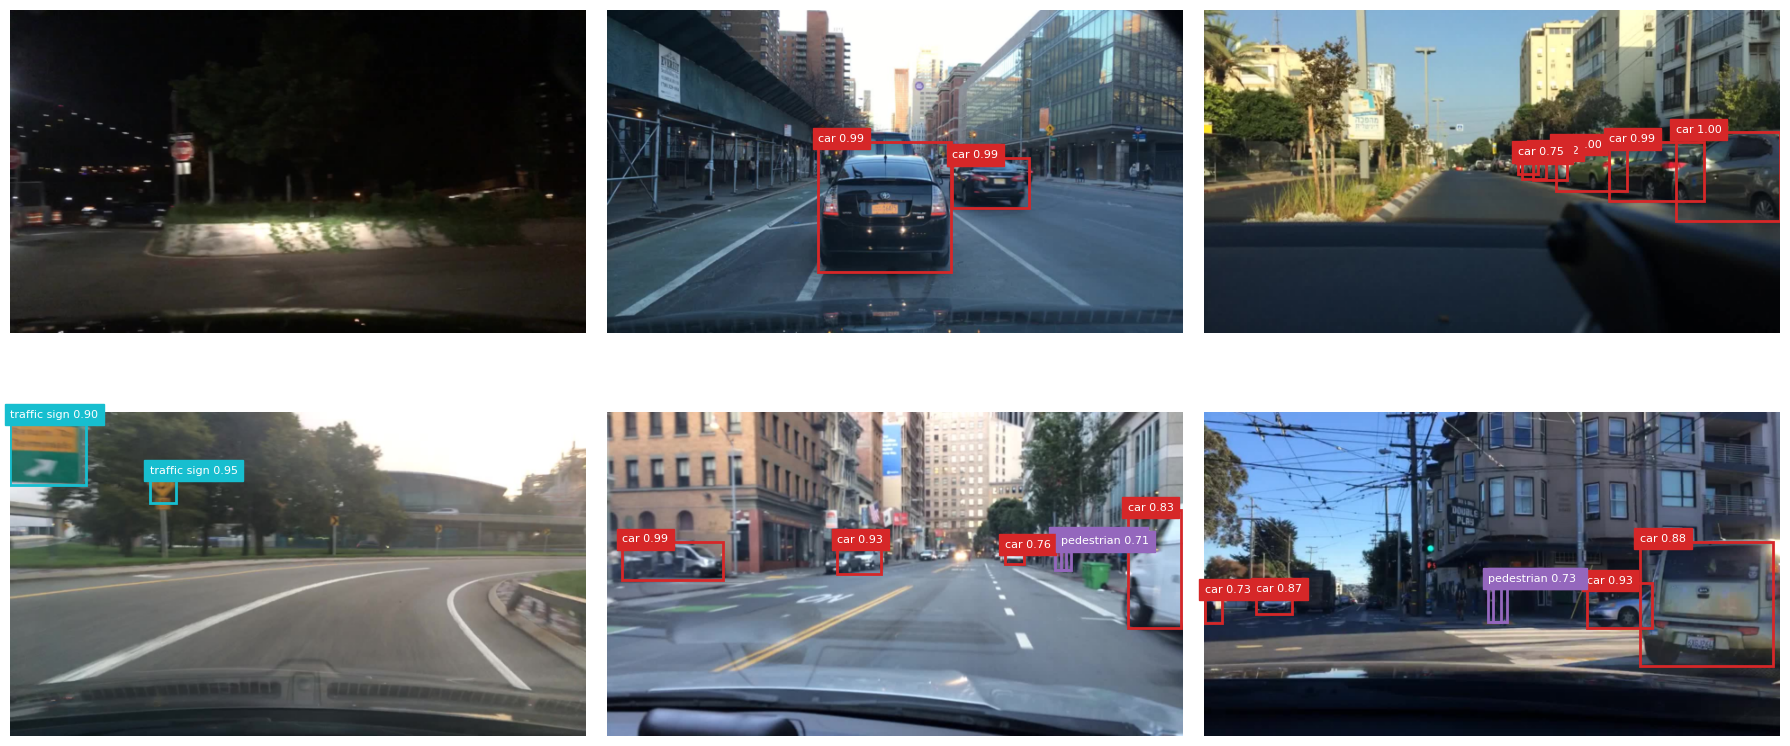

In [11]:
COLORS = ["#d62728", "#2ca02c", "#1f77b4", "#9467bd", "#ff7f0e", "#17becf"]
display_ds = final_test_ds if final_test_ds is not None else final_val_ds
indices = np.linspace(0, len(display_ds) - 1, min(6, len(display_ds)), dtype=int)
images = [display_ds[int(index)][0] for index in indices]
with torch.inference_mode():
    outputs = model([image.to(DEVICE) for image in images])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, image, output in zip(axes.flat, images, outputs):
    axis.imshow(image.permute(1, 2, 0).clamp(0, 1))
    keep = output["scores"].detach().cpu() >= live_val.score_threshold
    for box, label, score in zip(
        output["boxes"].detach().cpu()[keep],
        output["labels"].detach().cpu()[keep],
        output["scores"].detach().cpu()[keep],
    ):
        x1, y1, x2, y2 = box.tolist()
        color = COLORS[(int(label) - 1) % len(COLORS)]
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=color, linewidth=2))
        axis.text(
            x1,
            y1,
            f"{PROJECT_CLASSES[int(label) - 1]} {float(score):.2f}",
            color="white",
            fontsize=8,
            backgroundcolor=color,
        )
    axis.axis("off")
plt.tight_layout()

## Final inference benchmark and live command

This benchmark includes model inference but not camera capture or drawing. The
checkpoint stores the balanced proposal configuration, so command-line loading uses
the same fast inference path.

In [12]:
benchmark_count = min(cfg["benchmark_images"], len(display_ds))
benchmark_images = [display_ds[index][0] for index in range(benchmark_count)]
with torch.inference_mode():
    for image in benchmark_images[: min(cfg["batch"], benchmark_count)]:
        model([image.to(DEVICE)])
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    started = time.perf_counter()
    for start in range(0, benchmark_count, cfg["batch"]):
        batch = [image.to(DEVICE) for image in benchmark_images[start:start + cfg["batch"]]]
        model(batch)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
elapsed = time.perf_counter() - started

print(f"Images: {benchmark_count}")
print(f"Total inference time: {elapsed:.3f} s")
print(f"Throughput: {benchmark_count / elapsed:.2f} images/s")
print(f"Average latency: {1000 * elapsed / benchmark_count:.1f} ms/image")
print()
print("Run from the project root:")
print(
    f"python RCNN_Live_Capture.py --weights \"{BEST_WEIGHTS}\" "
    f"--conf {live_val.score_threshold:.2f} --device 0"
)

Images: 100
Total inference time: 16.918 s
Throughput: 5.91 images/s
Average latency: 169.2 ms/image

Run from the project root:
python RCNN_Live_Capture.py --weights "c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\models\fasterrcnn_02b\rtx3050_fast_best.pth" --conf 0.70 --device 0
